<a href="https://colab.research.google.com/github/sisi-y/kenya-crop-yield-predictor/blob/main/Project2_CropYield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
print("Kenya Crop Yield Predictor - Starting...")
print("=" * 50)

Kenya Crop Yield Predictor - Starting...


In [7]:
np.random.seed(42)
n = 300
rainfall_mm   =np.random.uniform(400, 1200, n)
fertiliser_kg   =np.random.uniform(10, 100, n)
farm_size_acres   =np.random.uniform(0.5, 10, n)

crop_yield_kg = (
    rainfall_mm * 0.8
    + fertiliser_kg * 12
    + farm_size_acres * 150
    +np.random.normal(0, 50, n)
)
df = pd.DataFrame({
    "Rainfall_mm": rainfall_mm,
    "Fertiliser_kg": fertiliser_kg,
    "Farm_Size_acres": farm_size_acres,
    "Crop_Yield_kg": crop_yield_kg
})

print(f"Dataset created: {df.shape[0]} farms")
print(df.head())
print()
print("Basic Statistics:")
print(df.describe().round(1))

Dataset created: 300 farms
   Rainfall_mm  Fertiliser_kg  Farm_Size_acres  Crop_Yield_kg
0   699.632095      14.651355         2.104883    1067.561051
1  1160.571445      57.821917         3.146608    2031.755712
2   985.595153      58.657161         2.181600    1865.803345
3   878.926787      67.368691         1.342674    1703.721727
4   524.814912      75.348220         1.646041    1544.800536

Basic Statistics:
       Rainfall_mm  Fertiliser_kg  Farm_Size_acres  Crop_Yield_kg
count        300.0          300.0            300.0          300.0
mean         796.2           56.0              5.0         2058.7
std          235.5           27.2              2.7          554.9
min          404.0           11.0              0.5          703.5
25%          591.3           32.5              2.5         1663.9
50%          809.4           57.0              4.8         2084.4
75%         1005.5           79.6              7.3         2438.6
max         1192.0          100.0             10.0    

In [8]:
# ---- STEP 2: PREPARE THE DATA ---- #
# X = inputs(features), y = output(targets)
X = df[["Rainfall_mm", "Fertiliser_kg", "Farm_Size_acres"]]
y = df["Crop_Yield_kg"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(f"Training farms: {len(X_train)}")
print(f"Training farms: {len(X_test)}")
print()

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained!")
print()

from sklearn.metrics import r2_score, mean_absolute_error
prediction = model.predict(X_test)
accuracy = r2_score(y_test, prediction)
mae = mean_absolute_error(y_test, prediction)

print("MODEL PERFORMANCE")
print(f"R^2 score: {accuracy*100:.1f}%")
print(f"Mean Absolute Error: +_ {mae:.0f}kg.")
print()

print("What this means:")
print(f"Our model explains {accuracy*100:.1f}% of the variation in crop yield.")
print(f"on average, predictions are off by about {mae:.0f}kg")

Training farms: 240
Training farms: 60

Model Trained!

MODEL PERFORMANCE
R^2 score: 98.7%
Mean Absolute Error: +_ 43kg.

What this means:
Our model explains 98.7% of the variation in crop yield.
on average, predictions are off by about 43kg


In [9]:
from sklearn.metrics import r2_score, mean_absolute_error
prediction = model.predict(X_test)
accuracy = r2_score(y_test, prediction)
mae = mean_absolute_error(y_test, prediction)

print("MODEL PERFORMANCE")
print(f"R^2 score: {accuracy*100:.1f}%")
print(f"Mean Absolute Error: +_ {mae:.0f}kg.")
print()

print("What this means:")
print(f"Our model explains {accuracy*100:.1f}% of the variation in crop yield.")
print(f"on average, predictions are off by about {mae:.0f}kg")

MODEL PERFORMANCE
R^2 score: 98.7%
Mean Absolute Error: +_ 43kg.

What this means:
Our model explains 98.7% of the variation in crop yield.
on average, predictions are off by about 43kg


In [10]:
# ---- STEP 5: PREDICT FOR REAL FARMS ---- #
import pandas as pd
def predict_farm(model, rainfall, fertiliser, farm_size, farm_name="Your Farm"):
  """predict crop yield for a specific farm"""
  farm_data = pd.DataFrame({
      "Rainfall_mm": [rainfall],
      "Fertiliser_kg": [fertiliser],
      "Farm_Size_acres": [farm_size]
  })
  predicted = model.predict(farm_data)[0]
  print(f"\n🌽 PREDICTION FOR: {farm_name}")
  print(f"Rainfall: {rainfall} mm")
  print(f"Fertiliser: {fertiliser} kg")
  print(f"Farm Size: {farm_size} acres")
  print(f"➡ Predicted Yield: {predicted:,.0f} kg of maize")
  return predicted

predict_farm(model, 600, 30, 1.5, "Small Farm in Nakuru")
predict_farm(model, 900, 60, 4.0, "Medium Farm in Kisumu")
predict_farm(model, 1100, 90, 8.0, "Large Farm in Rift Valley")


🌽 PREDICTION FOR: Small Farm in Nakuru
Rainfall: 600 mm
Fertiliser: 30 kg
Farm Size: 1.5 acres
➡ Predicted Yield: 1,065 kg of maize

🌽 PREDICTION FOR: Medium Farm in Kisumu
Rainfall: 900 mm
Fertiliser: 60 kg
Farm Size: 4.0 acres
➡ Predicted Yield: 2,047 kg of maize

🌽 PREDICTION FOR: Large Farm in Rift Valley
Rainfall: 1100 mm
Fertiliser: 90 kg
Farm Size: 8.0 acres
➡ Predicted Yield: 3,175 kg of maize


np.float64(3174.963717711329)

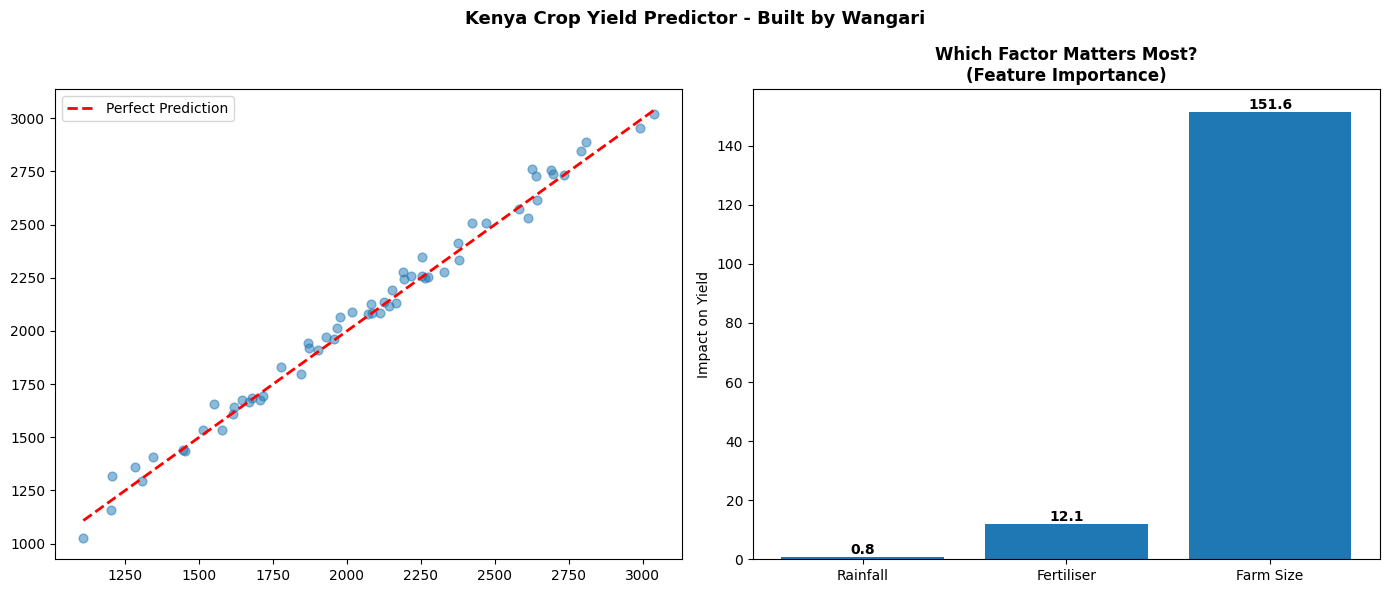

Project Complete!


In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(y_test, prediction, alpha=0.5, s=40)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Prediction'
)
axes[0].legend()


features = ["Rainfall", "Fertiliser", "Farm Size"]
importance = np.abs(model.coef_)
bars = axes[1].bar(features, importance)

axes[1].set_title(
    'Which Factor Matters Most?\n(Feature Importance)',
    fontweight='bold'
)
axes[1].set_ylabel('Impact on Yield')
for bar, val in zip(bars, importance):
  axes[1].text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height(),
      f'{val:.1f}',
      ha='center',
      va='bottom',
      fontweight='bold'
  )

plt.suptitle(
    'Kenya Crop Yield Predictor - Built by Wangari',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()
print("Project Complete!")